# Landsat 8 OLI Level-2 Download for Alegre (ES)

This notebook fetches surface reflectance data for the scene `LC08_L2SP_216074_20250711_20250725_02_T1`, covering Alegre, Espírito Santo, Brazil. The target date matches the explicit AWS Open Data S3 path that stores the requested Jul-2025 acquisition.

**Reference**: Instructions follow the [AWS Open Data Landsat Collection 2 registry](https://registry.opendata.aws/usgs-landsat/index.html). Because `usgs-landsat` is a requester-pays bucket, this notebook relies on configured AWS credentials to copy the Level-2 `B2`, `B3`, `B4`, and `QA_PIXEL` assets from `s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/216/074/LC08_L2SP_216074_20250711_20250725_02_T1/` into `../data/landsat/<scene_id>` without checking cloud cover or alternative dates.

In [7]:
import boto3
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt

In [9]:
aws_registry_url = "https://registry.opendata.aws/usgs-landsat/index.html"
bucket_name = "usgs-landsat"
scene_prefix = "collection02/level-2/standard/oli-tirs/2025/216/074/LC08_L2SP_216074_20250711_20250725_02_T1/"
asset_suffixes = ["SR_B2", "SR_B3", "SR_B4", "QA_PIXEL", "thumb_large"]
requester_pays_args = {"RequestPayer": "requester"}

s3_client = boto3.client("s3")

scene_id = scene_prefix.rstrip("/").split("/")[-1]
local_data_root = Path("../data/landsat")
local_scene_dir = local_data_root / scene_id
local_scene_dir.mkdir(parents=True, exist_ok=True)

asset_list = ", ".join(asset_suffixes)
print(f"Prepared local folder: {local_scene_dir.resolve()}")
print(f"Target assets: {asset_list}")

Prepared local folder: /Volumes/workplace/Projects/carbono-data-collection/data/landsat/LC08_L2SP_216074_20250711_20250725_02_T1
Target assets: thumb_large


In [12]:
paginator = s3_client.get_paginator("list_objects_v2")
all_scene_keys = []

for page in paginator.paginate(Bucket=bucket_name, Prefix=scene_prefix, **requester_pays_args):
    if "Contents" in page:
        for obj in page["Contents"]:
            all_scene_keys.append(obj["Key"])

selected_keys = []
for key in all_scene_keys:
    for suffix in asset_suffixes:
        if suffix == "thumb_large":
            if key.endswith("_thumb_large.jpg") or key.endswith("_thumb_large.jpeg"):
                selected_keys.append(key)
                break
        else:
            if key.endswith(f"_{suffix}.TIF"):
                selected_keys.append(key)
                break

print("Found remote assets:")
for key in selected_keys:
    print(f" - {key}")

Found remote assets:
 - collection02/level-2/standard/oli-tirs/2025/216/074/LC08_L2SP_216074_20250711_20250725_02_T1/LC08_L2SP_216074_20250711_20250725_02_T1_thumb_large.jpeg


In [13]:
for key in selected_keys:
    filename = key.split("/")[-1]
    destination_path = local_scene_dir / filename
    if destination_path.exists():
        print(f"Skipping existing {destination_path.name}")
        continue
    s3_client.download_file(Bucket=bucket_name, Key=key, Filename=str(destination_path), ExtraArgs=requester_pays_args)
    print(f"Downloaded {filename} -> {destination_path}")

Downloaded LC08_L2SP_216074_20250711_20250725_02_T1_thumb_large.jpeg -> ../data/landsat/LC08_L2SP_216074_20250711_20250725_02_T1/LC08_L2SP_216074_20250711_20250725_02_T1_thumb_large.jpeg


After the downloads complete you can visualize the GeoTIFFs in the `../data/landsat/LC08_L2SP_216074_20250711_20250725_02_T1/` directory with `rasterio`, `matplotlib`, or any GIS tool.

(np.float64(-0.5), np.float64(7590.5), np.float64(7700.5), np.float64(-0.5))

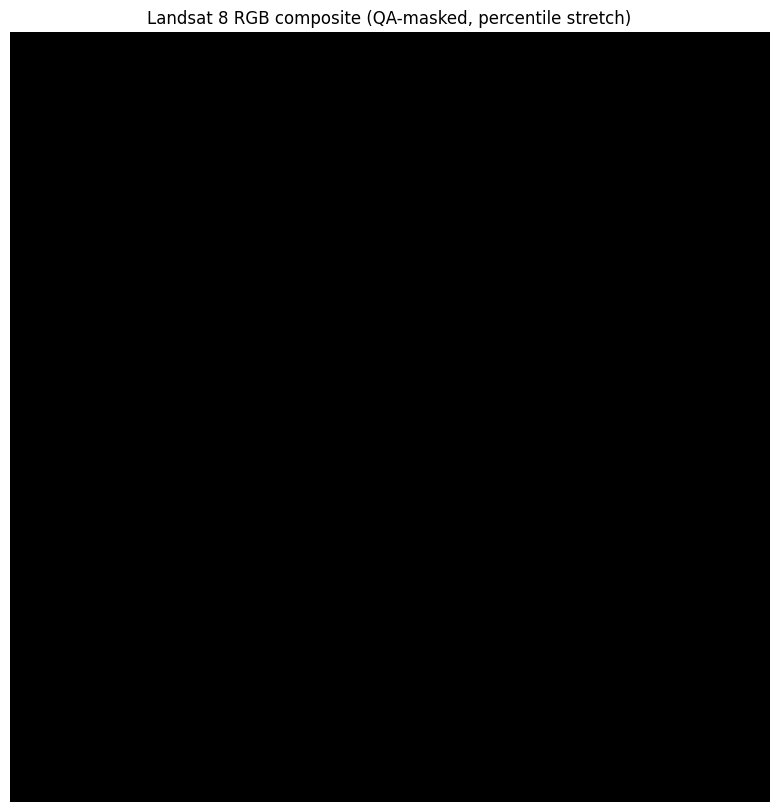

In [18]:
band_suffix_map = [('red', 'SR_B4'), ('green', 'SR_B3'), ('blue', 'SR_B2')]
band_arrays = []

for _, suffix in band_suffix_map:
    band_path = local_scene_dir / f"{scene_id}_{suffix}.TIF"
    with rasterio.open(band_path) as src:
        band_arrays.append(src.read(1).astype('float32'))

qa_path = local_scene_dir / f"{scene_id}_QA_PIXEL.TIF"
with rasterio.open(qa_path) as src:
    qa_pixel = src.read(1)

qa_mask = np.zeros_like(qa_pixel, dtype=bool)
qa_mask |= (qa_pixel & 1) != 0
qa_mask |= (qa_pixel & (1 << 1)) != 0
qa_mask |= (qa_pixel & (1 << 3)) != 0
qa_mask |= (qa_pixel & (1 << 4)) != 0
rgb_stack = np.stack(band_arrays, axis=-1)
rgb_stack = np.where(qa_mask[..., None], np.nan, rgb_stack)

low_percentile = np.nanpercentile(rgb_stack, 0)
high_percentile = np.nanpercentile(rgb_stack, 100)
scale_denominator = max(high_percentile - low_percentile, 1e-6)
rgb_stretched = np.clip((rgb_stack - low_percentile) / scale_denominator, 0, 1)
rgb_stretched = np.nan_to_num(rgb_stretched)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_stretched)
plt.title('Landsat 8 RGB composite (QA-masked, percentile stretch)')
plt.axis('off')


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

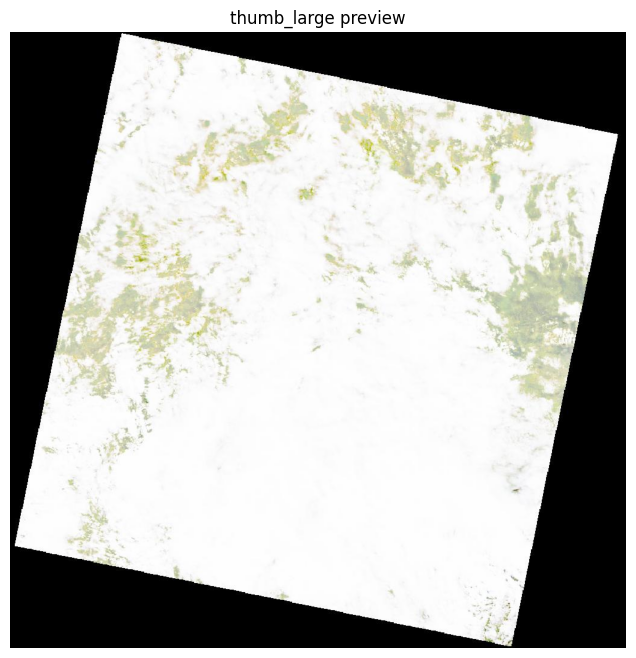

In [19]:
thumb_path_jpeg = local_scene_dir / f"{scene_id}_thumb_large.jpg"
thumb_path_alt = local_scene_dir / f"{scene_id}_thumb_large.jpeg"
thumb_path = thumb_path_jpeg if thumb_path_jpeg.exists() else thumb_path_alt
if not thumb_path.exists():
    raise FileNotFoundError("thumb_large image not found in local scene directory")
thumb_image = plt.imread(thumb_path)
plt.figure(figsize=(8, 8))
plt.imshow(thumb_image)
plt.title("thumb_large preview")
plt.axis("off")